# Loading fragments and making multimodal embedding

If you have multimodal, multi-experiment data, you can use this notebook to load the fragments.

In [1]:
import matplotlib.pyplot as plt

import numpy as np
import anndata as ad
import pandas as pd
import sys

sys.path.insert(0, '..')
import src as scit

In [2]:
# m39 = scit.tl.get_genome_dict('GRCm39')
# For mouse ^
dm6 = scit.tl.get_genome_dict('DM6')

In [ ]:
rep1ac = scit.ld.fragments(
    "private/data/mutant/fragments/rep1/H3K27ac/fragments.tsv",
    dm6,
    ignore_missing_chr=True
)
rep2ac = scit.ld.fragments(
    "private/data/mutant/fragments/rep2/H3K27ac/fragments.tsv",
    dm6,
    ignore_missing_chr=True
)


In [ ]:
rep1me = scit.ld.fragments(
    "private/data/mutant/fragments/rep1/H3K27me3/fragments.tsv",
    dm6,
    ignore_missing_chr=True
)
rep2me = scit.ld.fragments(
    "private/data/mutant/fragments/rep2/H3K27me3/fragments.tsv",
    dm6,
    ignore_missing_chr=True
)


In [20]:
for a, name in ((rep1ac, 'rep1ac'), (rep2ac, 'rep2ac'), (rep1me, 'rep1me'), (rep2me, 'rep2me')):
    a.write_h5ad(f"private/data/mutant/{name}.h5ad",)

In [64]:
rep1ac = ad.read_h5ad('private/data/mutant/rep1ac.h5ad')
rep2ac = ad.read_h5ad('private/data/mutant/rep2ac.h5ad')
rep1me = ad.read_h5ad('private/data/mutant/rep1me.h5ad')
rep2me = ad.read_h5ad('private/data/mutant/rep2me.h5ad')

In [65]:
# Stack datas into one AnnData
rep1 = scit.tl.stack_adata([rep1ac, rep1me], ['acet', 'meth'])
rep2 = scit.tl.stack_adata([rep2ac, rep2me], ['acet', 'meth'])
rep1.write_h5ad('private/data/mutant/combined_rep1.h5ad')
rep2.write_h5ad('private/data/mutant/combined_rep2.h5ad')

Info: found 27402 obs shared between all adatas...
Info: found 27513 var shared between all adatas...


/home/aleksander/Skrivbord/pyproject/notebooks/../src/tools/_combine.py:61: ImplicitModificationWarning: Setting element `.layers['acet']` of view, initializing view as actual.
  _adata.layers[layer_names[i]] = adatas[i].X.copy()


Info: found 27215 obs shared between all adatas...
Info: found 27513 var shared between all adatas...


/home/aleksander/Skrivbord/pyproject/notebooks/../src/tools/_combine.py:61: ImplicitModificationWarning: Setting element `.layers['acet']` of view, initializing view as actual.
  _adata.layers[layer_names[i]] = adatas[i].X.copy()


In [2]:
rep1 = ad.read_h5ad('private/data/mutant/combined_rep1.h5ad')
rep2 = ad.read_h5ad('private/data/mutant/combined_rep2.h5ad')

/home/aleksander/Skrivbord/pyproject/notebooks/../src/plotting/_hist.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plw.ax.set_xticklabels(xticks)


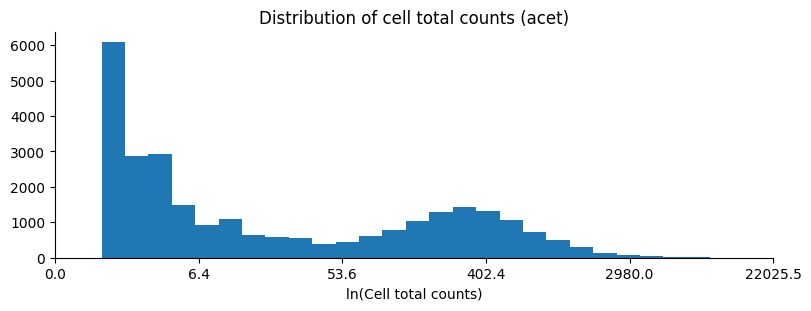

/home/aleksander/Skrivbord/pyproject/notebooks/../src/plotting/_hist.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plw.ax.set_xticklabels(xticks)


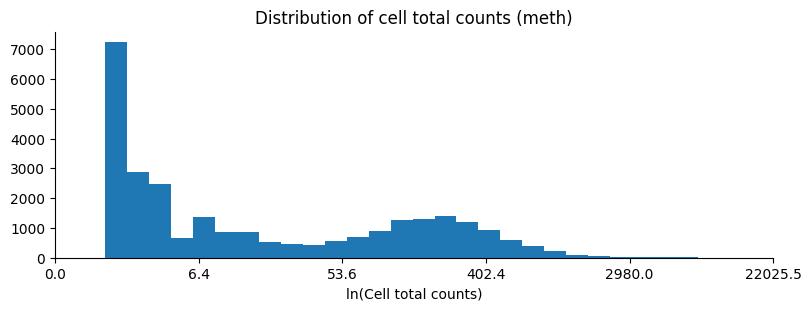

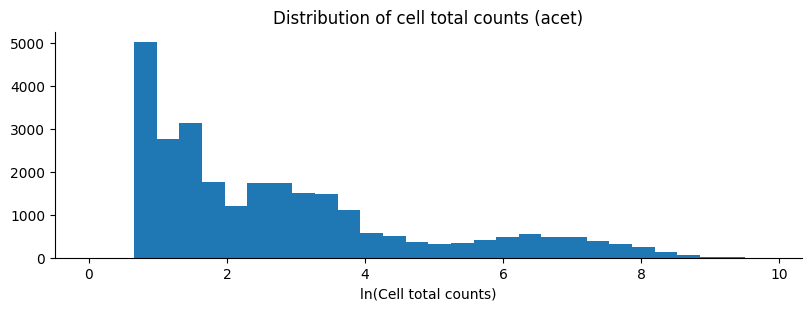

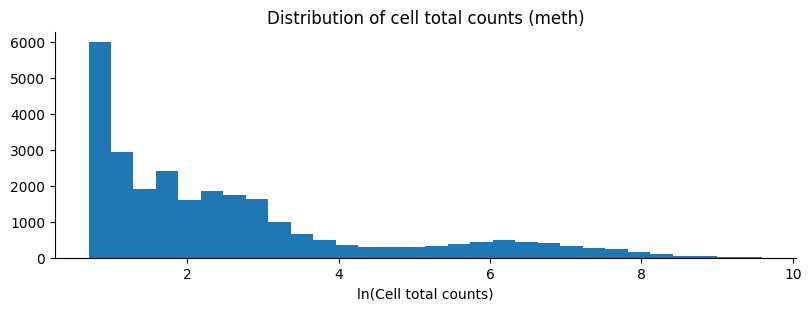

In [3]:
scit.tl.add_metadata(rep1)
scit.tl.add_metadata(rep2)
scit.set_defaults(figsize=(8,3))
scit.pl.cell_counts_histogram(rep1, xminmax=(0,10), label_exp=True)
scit.pl.cell_counts_histogram(rep2)

/home/aleksander/Skrivbord/pyproject/notebooks/../src/plotting/_hist.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plw.ax.set_xticklabels(xticks)


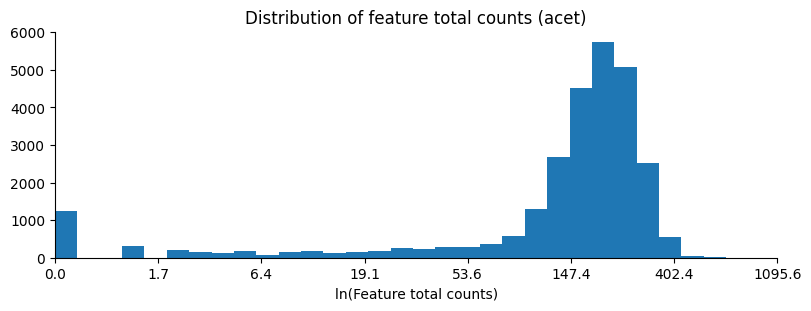

/home/aleksander/Skrivbord/pyproject/notebooks/../src/plotting/_hist.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plw.ax.set_xticklabels(xticks)


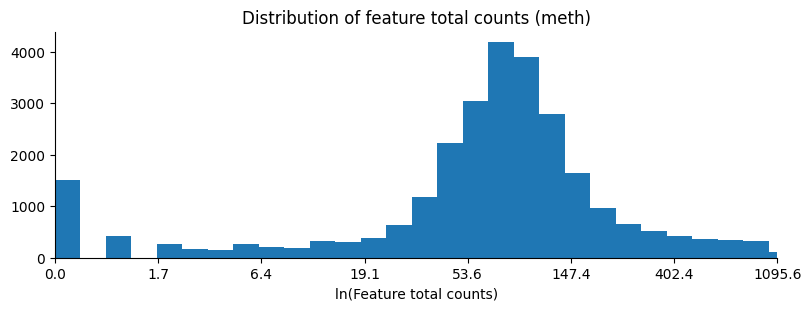

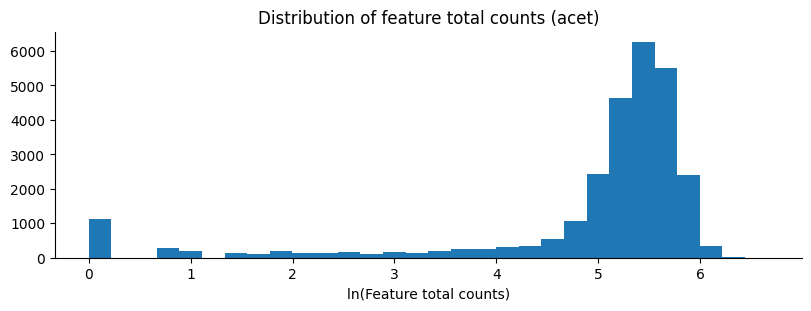

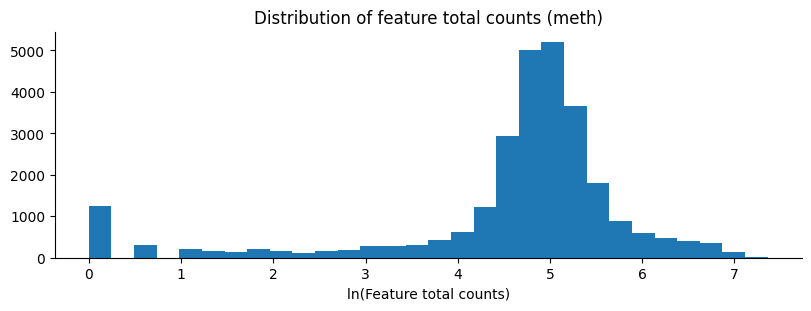

In [4]:
scit.pl.feature_counts_histogram(rep1, xminmax=(0, 7), label_exp=True)
scit.pl.feature_counts_histogram(rep2)

In [50]:
rep1 = scit.tl.filter(
    rep1, ['acet', 'meth'], 
    min_obs_counts=[obs_rep1_th, obs_rep1_th], 
    max_obs_counts=[98j, 98j], 
    return_purged=True
)

Info: The 98.0th percentile of obs total counts is 1332.9799999999996
Info: The 98.0th percentile of obs total counts is 859.0


In [51]:
rep2 = scit.tl.filter(
    rep2, ['acet', 'meth'], 
    min_obs_counts=[obs_rep2_th, obs_rep2_th], 
    max_obs_counts=[obs_rep2_max, obs_rep2_max], 
    return_purged=True
)

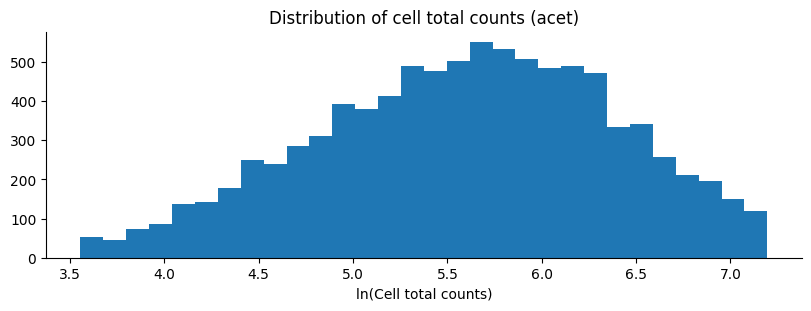

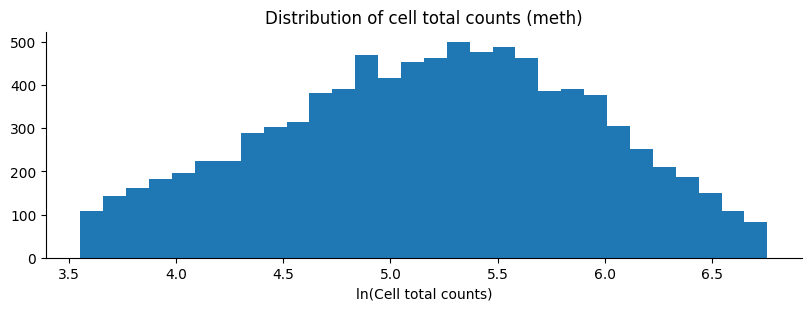

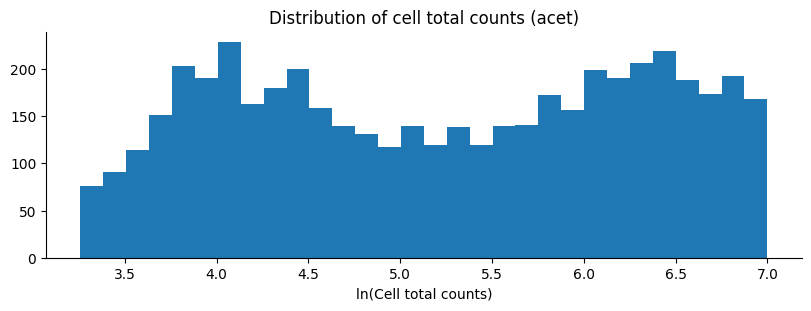

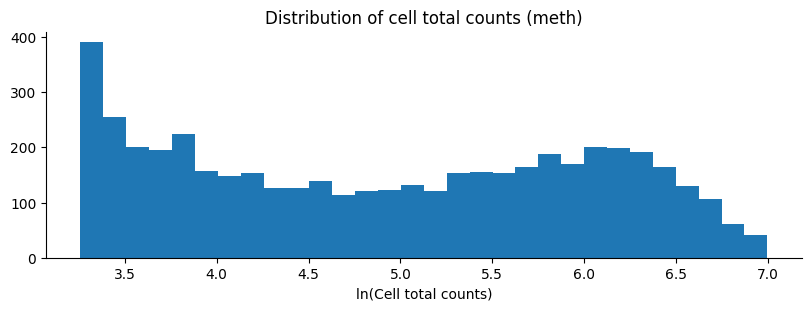

In [52]:
scit.tl.add_metadata(rep1)
scit.pl.cells_counts_histogram(rep1)
scit.tl.add_metadata(rep2)
scit.pl.cells_counts_histogram(rep2)

In [53]:
rep1.obs['rep'] = 'rep1'
rep1.obs_names = [f"{oi}R1" for oi in rep1.obs_names]
rep2.obs_names = [f"{oi}R2" for oi in rep2.obs_names]
rep2.obs['rep'] = 'rep2'

# Same var
assert rep2.shape[1] == np.intersect1d(rep2.var_names, rep1.var_names).shape[0]

In [54]:
adata = ad.concat([rep1, rep2])
assert (adata.var_names == rep1.var_names).all()
import pandas as pd; adata.obs['rep'] = pd.Categorical(adata.obs['rep'])
adata.var = rep1.var.copy()

In [55]:
adata=scit.tl.filter(
   adata, ['acet', 'meth'], 
    min_var_counts=[5, 5], return_purged=True
)

In [56]:
# Soft filter
scit.tl.filter(
   adata, ['acet', 'meth'], 
    min_var_counts=[15, 15]
)

Info: Adata not modified. If you want to remove excluded cells and bins, use return_purged = True or remove them manually


In [57]:
layers = ['acet', 'meth']
layer_keys = ['X_acetylation', 'X_methylation']
scit.set_defaults(figsize=(12,5))

for i in range(len(layers)):
    print(scit.em.spectral(adata, layers[i]))
    adata.obsm[layer_keys[i]] = adata.obsm['X_spectral'].copy()
    del adata.obsm['X_spectral']
    scit.tl.remove_pc(adata, layer_keys[i], 0)

[1.         0.02666442 0.02433076 0.02387771 0.02034446 0.01998535
 0.01942497 0.0190475  0.01896891 0.01888129 0.01885441 0.01885027
 0.01875189 0.01873815 0.018689   0.01868474 0.01861821 0.01859637
 0.01858482 0.01854435 0.0185144  0.01849045 0.01847507 0.01845991
 0.01842631]
[1.         0.06041139 0.04423345 0.03043133 0.02825825 0.02638564
 0.02540112 0.02411829 0.02408729 0.02395088 0.02386092 0.02379947
 0.02377181 0.02374471 0.02367838 0.02362991 0.02357893 0.02352079
 0.02348682 0.02339969 0.02335605 0.02331366 0.02328754 0.02324258
 0.02319616]


In [58]:
print(scit.em.multiview_spectral(adata, ['acet', 'meth']))

[1.         0.03939502 0.02865098 0.02089308 0.02027947 0.01809664
 0.01587813 0.01521827 0.01466774 0.01417862 0.01379941 0.01370538
 0.01368052 0.01365585 0.01362839 0.01359595 0.01354949 0.01352741
 0.01351006 0.01347579 0.01343784 0.01343437 0.01342143 0.01341019
 0.0133846 ]


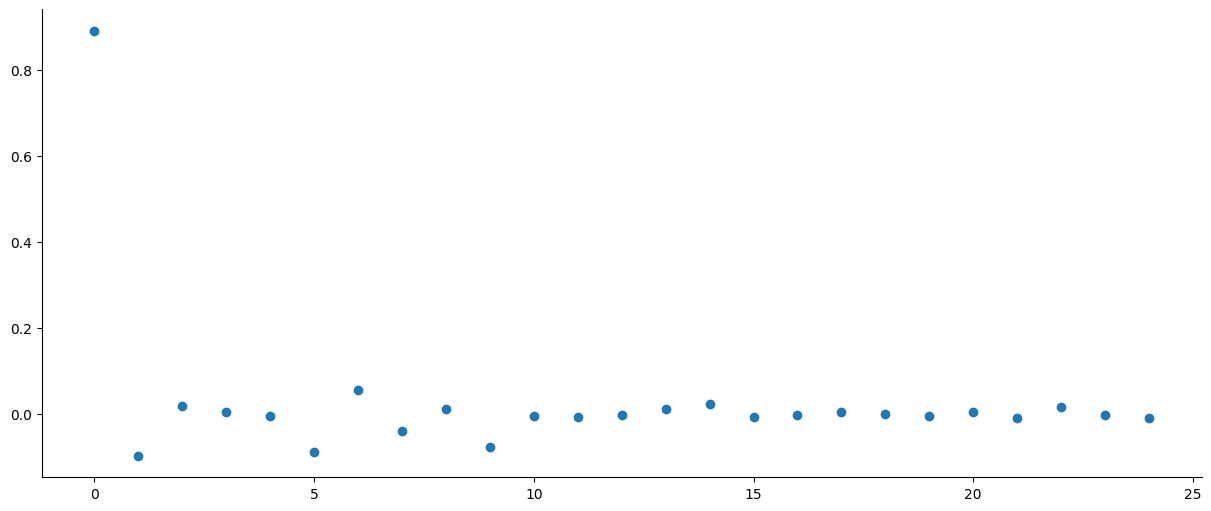

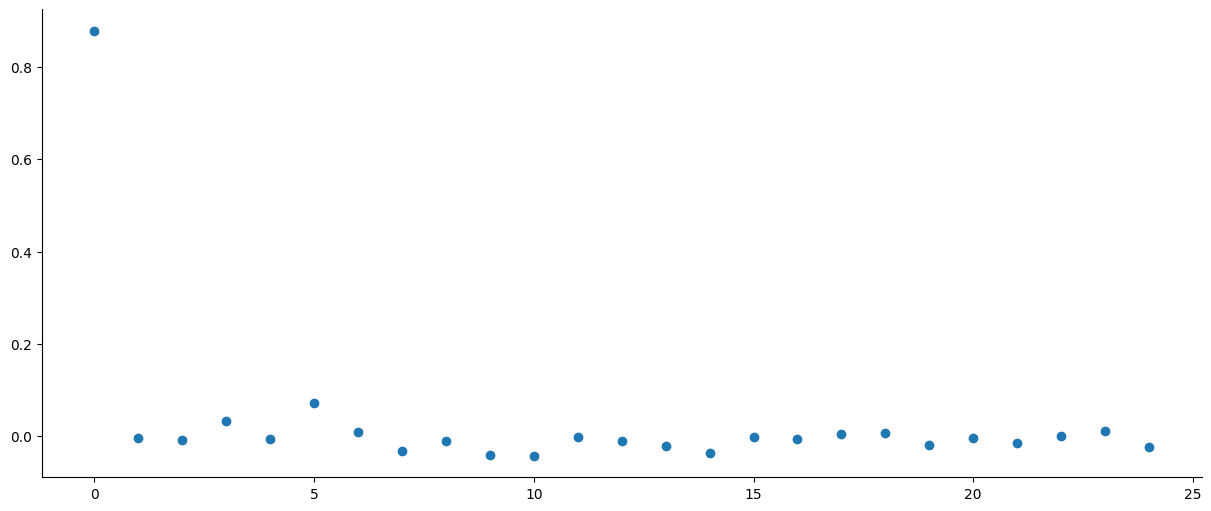

In [59]:
scit.pl.depth_corr(adata, 'X_multi_spectral', 'acet')
scit.pl.depth_corr(adata, 'X_multi_spectral', 'meth')

In [60]:
scit.tl.remove_pc(adata, 'X_multi_spectral', 0)

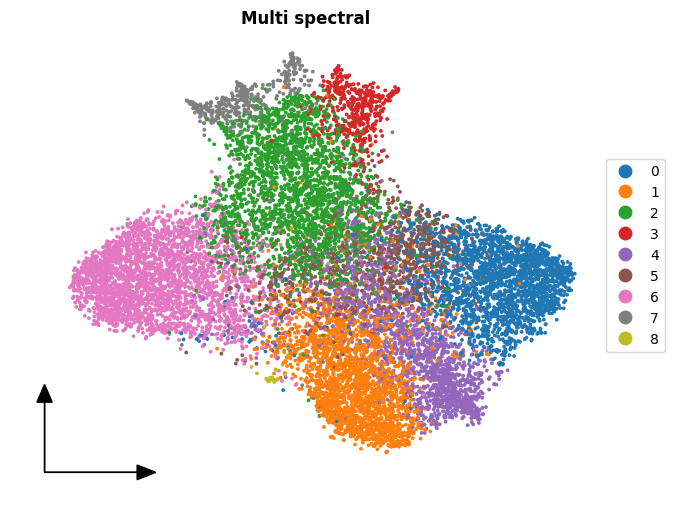

In [61]:
scit.em.umap(adata, 'X_multi_spectral', n_neighbors=10)
scit.gr.knn(adata, 'X_multi_spectral', n_neighbors=10)
g = scit.gr.neighbor_graph(adata)
scit.gr.leiden(adata, g, 1)
scit.set_defaults(figsize=(6,5))
scit.pl.embedding2d(adata, 'X_umap', 'leiden', title=f'Multi spectral')

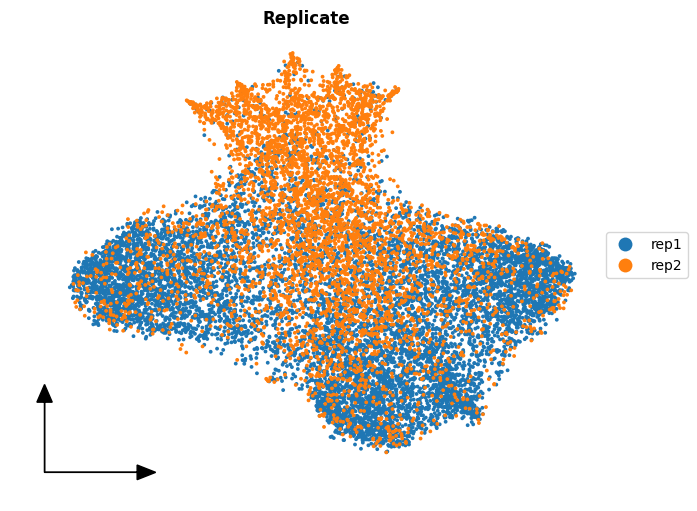

In [62]:
scit.pl.embedding2d(adata, 'X_umap', 'rep', title=f'Replicate')

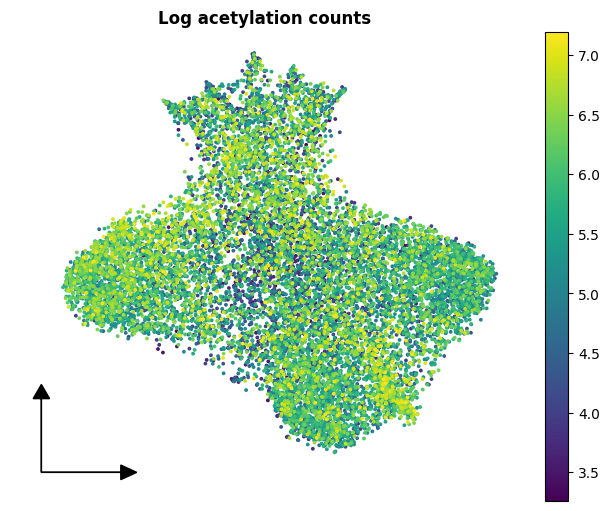

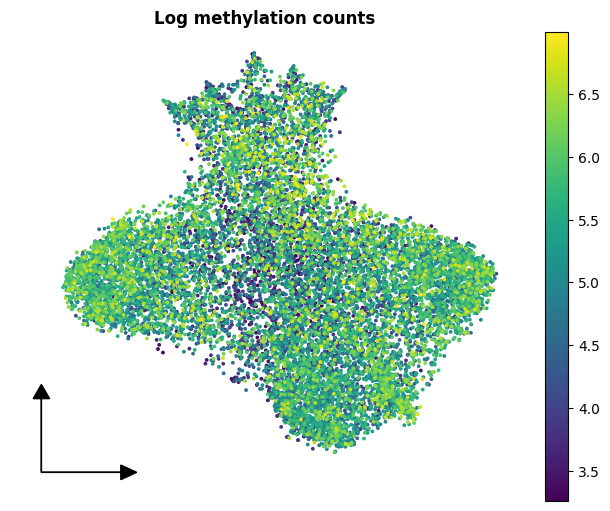

In [63]:
scit.pl.embedding2d(adata, 'X_umap', 'acet_log_total_counts', title='Log acetylation counts')
scit.pl.embedding2d(adata, 'X_umap', 'meth_log_total_counts', title='Log methylation counts')

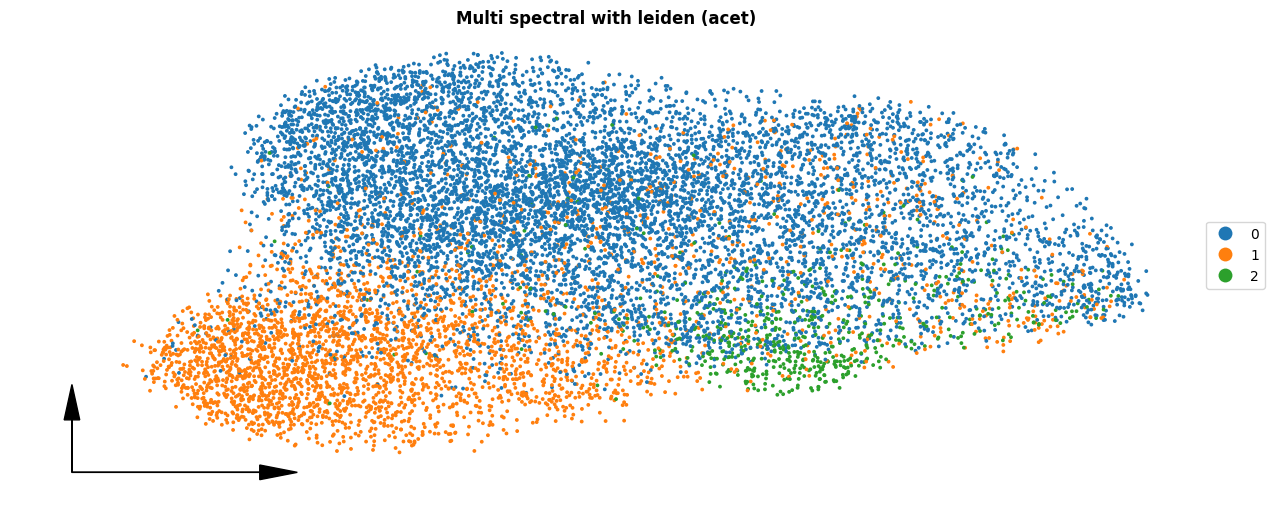

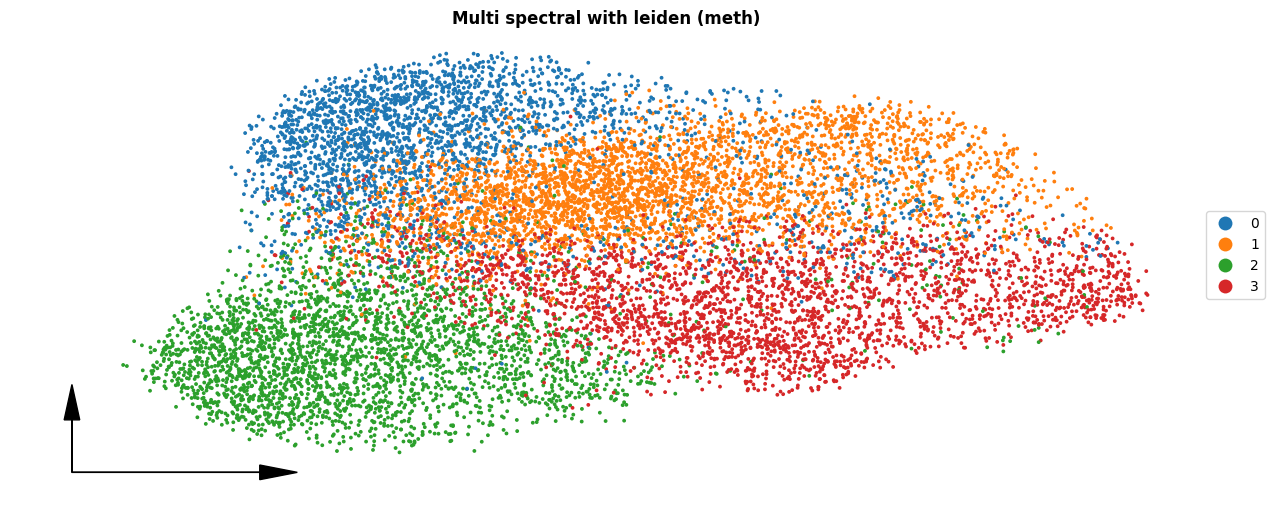

In [79]:
for i in range(len(layers)):
    scit.gr.knn(adata, layer_keys[i], n_neighbors=50)
    g = scit.gr.neighbor_graph(adata)
    scit.gr.leiden(adata, g, 0.5)
    scit.pl.embedding2d(adata, 'X_umap', 'leiden', title=f'Multi spectral with leiden ({layers[i]})')

In [66]:
adata.write_h5ad('private/data/mutant/combined.h5ad')